# NEUROFLUX DATASET ANALYSIS

In [1]:
import os
import yaml
import torch
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import sys

sys.path.append(os.path.abspath("../src"))
from data.prepare_dataset import load_data


## Load configuration file and create datasets train/val/test

In [2]:
config_file = r'C:\Users\guill\Documents\github_projects\neuroflux-classification\configs\config.yaml'
with open(config_file, "r") as f:
    config = yaml.safe_load(f)
    
#____ Load the config file to create train/val/test dataset
train_ds, val_ds, test_ds = load_data(config)

### Count occurence in each datasets

In [3]:
def count_labels(dataset):
    return Counter([label for _, label in dataset])

label_names = config["general"]["class_names"]

counts = {
    "train": count_labels(train_ds),
    "val": count_labels(val_ds),
    "test": count_labels(test_ds)
}

rows = []
for split, counter in counts.items():
    for class_idx, count in counter.items():
        class_name = label_names[class_idx]
        rows.append({"split": split, "class": class_name, "count": count})

df = pd.DataFrame(rows)
pivot = df.pivot(index="class", columns="split", values="count").fillna(0).astype(int)

### Transform to percentage and display tab

In [4]:
totals = {
    split: pivot[split].sum() for split in ["train", "val", "test"]
}
pivot_percent = pivot[["train", "val", "test"]].copy()

#_____ Compute percentage
for split in ["train", "val", "test"]:
    pivot_percent[f"{split}_pct"] = (pivot_percent[split] / totals[split] * 100).round(1).astype(str) + "%"

pivot_percent["total"] = pivot_percent[["train", "val", "test"]].sum(axis=1)
pivot_percent["total_pct"] = (pivot_percent["total"] / pivot_percent["total"].sum() * 100).round(1).astype(str) + "%"

cols = []
for split in ["train", "val", "test"]:
    cols.extend([split, f"{split}_pct"])
cols += ["total", "total_pct"]

pivot_percent = pivot_percent[cols]
pivot_percent

split,train,train_pct,val,val_pct,test,test_pct,total,total_pct
class,,,,,,,,
EO,162,17.9%,47,18.1%,24,18.5%,233,18.0%
IO,50,5.5%,15,5.8%,7,5.4%,72,5.6%
IPTE,120,13.2%,34,13.1%,17,13.1%,171,13.2%
LO,168,18.5%,48,18.5%,24,18.5%,240,18.5%
PTE,406,44.8%,116,44.6%,58,44.6%,580,44.8%


### Display graph and compute imbalanced ratio

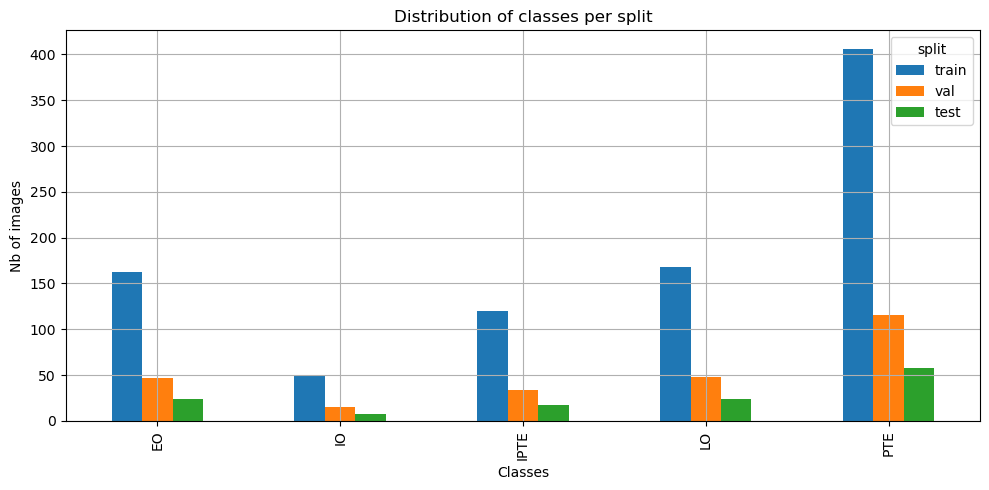

In [5]:
pivot[["train", "val", "test"]].plot(kind="bar", figsize=(10, 5))
plt.title("Distribution of classes per split")
plt.xlabel("Classes")
plt.ylabel("Nb of images")
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
total_images = pivot_percent["total"].sum()
imbalance_ratio = pivot_percent["total"].max() / max(1, pivot_percent["total"].min())
print(f"Total images: {total_images}")
print(f"Ratio max/min (imbalanced): {imbalance_ratio:.2f}")

Total images: 1296
Ratio max/min (imbalanced): 8.06


--> De ce que l'on peut observer c'est qu'il y a un sacré déséquilibre des classes entre PTE et IO. c'est à dire que PTE est sur-représenté dans les différents datasets. 

--> Tandis qu'inversement IO est sous représenté ce qui peut induire une mauvaise généralisation. 
 Les autres quantités semblent correctes en termes de distribution. 
 
--> IPTE également a l'air d'être pas très bien représenté en terme de proportion. 

 --> Dans le training, il faut peut être rajouter de la Data Aug, d'utiliser un weightRandomSampler pour que le modèle voit un peu plus de données IO et IPTE